In [8]:
# ========== 块 1：数据 ==========
import pandas as pd
import numpy as np
import sqlite3
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

n = 10000  # 1万用户

# 用户维度表
users = pd.DataFrame({
    'user_id': range(1, n+1),
    'experiment_group': np.random.choice(['control', 'treatment'], n, p=[0.5, 0.5]),
    'device': np.random.choice(['ios', 'android', 'pc'], n, p=[0.4, 0.4, 0.2]),
    'user_type': np.random.choice(['new', 'old'], n, p=[0.6, 0.4]),
    'city_tier': np.random.choice([1, 2, 3, 4], n, p=[0.2, 0.3, 0.3, 0.2])
})

# 实验效果：treatment 转化率比 control 高 3 个百分点
# 老用户、ios 设备、1线城市 效果更好（异质性）
def get_conversion(row):
    base = 0.10
    if row['experiment_group'] == 'treatment':
        base += 0.03
    if row['user_type'] == 'old':
        base += 0.02
    if row['device'] == 'ios':
        base += 0.01
    if row['city_tier'] == 1:
        base += 0.01
    return np.random.binomial(1, min(base, 0.95))

users['converted'] = users.apply(get_conversion, axis=1)


users['revenue'] = users.apply(
    lambda x: np.random.normal(210, 50) if x['converted']==1 and x['experiment_group']=='treatment'
    else (np.random.normal(180, 45) if x['converted']==1 else 0), axis=1
)
users['revenue'] = users['revenue'].clip(lower=0)

# 创建内存 SQLite 数据库（模拟数仓）
conn = sqlite3.connect(':memory:')
users.to_sql('user_exp', conn, index=False)

print("数据生成完成：", users.shape)
print(users.head())
print("\n实验组分布：")
print(users['experiment_group'].value_counts())

数据生成完成： (10000, 7)
   user_id experiment_group   device user_type  city_tier  converted  revenue
0        1          control      ios       old          3          0      0.0
1        2        treatment      ios       new          2          0      0.0
2        3        treatment      ios       new          4          0      0.0
3        4        treatment  android       old          2          0      0.0
4        5          control  android       new          3          0      0.0

实验组分布：
experiment_group
control      5076
treatment    4924
Name: count, dtype: int64


In [9]:
# ========== 块 2：SQL 取数 ==========

# 2.1 总体实验效果
query1 = """
SELECT 
    experiment_group,
    COUNT(*) as users,
    SUM(converted) as converters,
    ROUND(AVG(converted), 4) as conversion_rate,
    ROUND(AVG(revenue), 2) as avg_revenue,
    ROUND(SUM(revenue), 2) as total_revenue
FROM user_exp
GROUP BY experiment_group
"""
df_overall = pd.read_sql(query1, conn)
print("【总体实验效果】")
print(df_overall)

# 2.2 分设备类型效果（分层分析）
query2 = """
SELECT 
    experiment_group,
    device,
    COUNT(*) as users,
    SUM(converted) as converters,
    ROUND(AVG(converted), 4) as conversion_rate,
    ROUND(AVG(revenue), 2) as avg_revenue
FROM user_exp
GROUP BY experiment_group, device
ORDER BY device, experiment_group
"""
df_device = pd.read_sql(query2, conn)
print("\n【分设备效果】")
print(df_device)

# 2.3 新老用户效果（异质性分析）
query3 = """
SELECT 
    experiment_group,
    user_type,
    COUNT(*) as users,
    SUM(converted) as converters,
    ROUND(AVG(converted), 4) as conversion_rate
FROM user_exp
GROUP BY experiment_group, user_type
ORDER BY user_type, experiment_group
"""
df_user_type = pd.read_sql(query3, conn)
print("\n【新老用户效果】")
print(df_user_type)

# 2.4 窗口函数：用户价值分层（RFM思路结合AB测试）
query4 = """
SELECT 
    user_id,
    experiment_group,
    converted,
    revenue,
    NTILE(4) OVER (ORDER BY revenue DESC) as revenue_quartile
FROM user_exp
WHERE converted = 1
"""
df_quartile = pd.read_sql(query4, conn)
print("\n【转化用户收入四分位】（窗口函数）")
print(df_quartile.head())

【总体实验效果】
  experiment_group  users  converters  conversion_rate  avg_revenue  \
0          control   5076         580           0.1143        21.04   
1        treatment   4924         707           0.1436        30.32   

   total_revenue  
0      106794.40  
1      149313.54  

【分设备效果】
  experiment_group   device  users  converters  conversion_rate  avg_revenue
0          control  android   2070         218           0.1053        19.52
1        treatment  android   1971         281           0.1426        30.25
2          control      ios   1984         273           0.1376        25.22
3        treatment      ios   1942         297           0.1529        32.57
4          control       pc   1022          89           0.0871        16.00
5        treatment       pc   1011         129           0.1276        26.14

【新老用户效果】
  experiment_group user_type  users  converters  conversion_rate
0          control       new   3031         342           0.1128
1        treatment       new   2

In [10]:
# ========== 块 3：Python 统计分析 ==========

# 3.1 转化率显著性检验（卡方检验）
control = users[users['experiment_group']=='control']
treatment = users[users['experiment_group']=='treatment']

# 构建列联表
contingency = pd.crosstab(users['experiment_group'], users['converted'])
print("列联表：")
print(contingency)

chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
print(f"\n卡方检验：chi2={chi2:.4f}, p_value={p_value:.6f}")
print("结论：", "实验显著（p<<0.05）" if p_value < 0.05 else "实验不显著（p>=0.05）")

# 3.2 计算相对提升率（Relative Uplift）和置信区间
c_rate = control['converted'].mean()
t_rate = treatment['converted'].mean()
uplift = (t_rate - c_rate) / c_rate
print(f"\n对照组转化率：{c_rate:.4f}")
print(f"实验组转化率：{t_rate:.4f}")
print(f"相对提升率：{uplift:.2%}")

# 3.3 收入显著性检验（t检验）
t_stat, p_val_rev = stats.ttest_ind(treatment['revenue'], control['revenue'])
print(f"\n收入t检验：t={t_stat:.4f}, p={p_val_rev:.6f}")

# 3.4 各子群体异质性分析
def ab_test_subgroup(df, group_col):
    results = []
    for val in df[group_col].unique():
        sub = df[df[group_col]==val]
        c = sub[sub['experiment_group']=='control']['converted'].mean()
        t = sub[sub['experiment_group']=='treatment']['converted'].mean()
        uplift = (t-c)/c if c>0 else 0
        results.append({
            group_col: val,
            'control_rate': c,
            'treatment_rate': t,
            'uplift': uplift
        })
    return pd.DataFrame(results)

print("\n【分设备提升率】")
print(ab_test_subgroup(users, 'device'))
print("\n【分用户类型提升率】")
print(ab_test_subgroup(users, 'user_type'))
print("\n【分城市等级提升率】")
print(ab_test_subgroup(users, 'city_tier'))

列联表：
converted            0    1
experiment_group           
control           4496  580
treatment         4217  707

卡方检验：chi2=18.8996, p_value=0.000014
结论： 实验显著（p<<0.05）

对照组转化率：0.1143
实验组转化率：0.1436
相对提升率：25.66%

收入t检验：t=6.7514, p=0.000000

【分设备提升率】
    device  control_rate  treatment_rate    uplift
0      ios      0.137601        0.152935  0.111441
1  android      0.105314        0.142567  0.353735
2       pc      0.087084        0.127596  0.465209

【分用户类型提升率】
  user_type  control_rate  treatment_rate    uplift
0       old      0.116381        0.151362  0.300571
1       new      0.112834        0.138341  0.226060

【分城市等级提升率】
   city_tier  control_rate  treatment_rate    uplift
0          3      0.117609        0.135962  0.156052
1          2      0.112630        0.146998  0.305138
2          4      0.113340        0.158107  0.394977
3          1      0.112550        0.135509  0.203995


In [11]:
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False


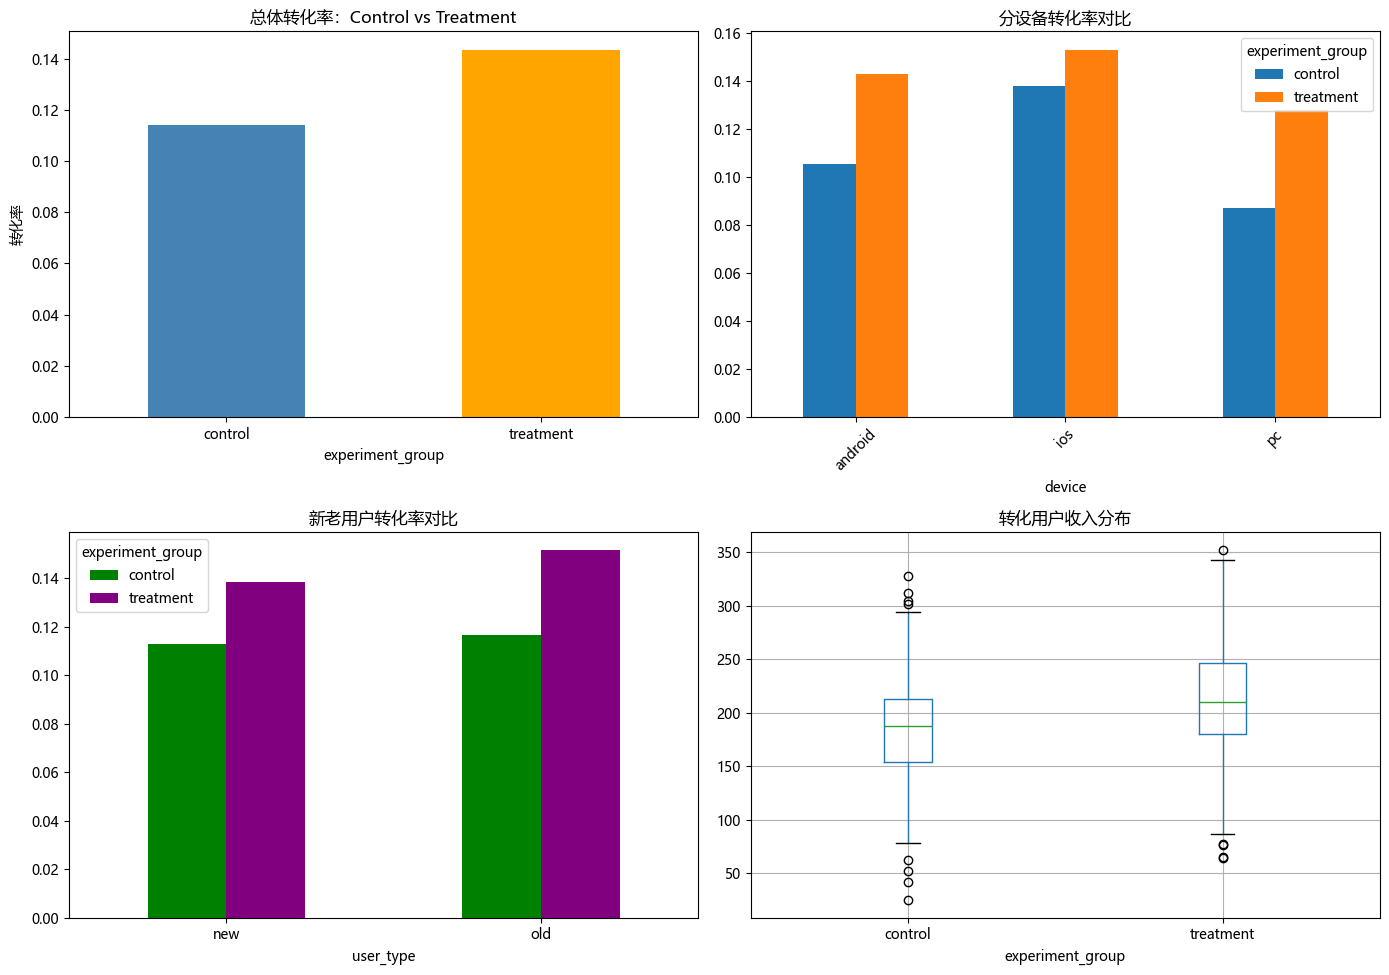

In [12]:
# ========== 块 4：可视化 ==========
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 图1：总体转化率对比
overall_rates = users.groupby('experiment_group')['converted'].mean()
overall_rates.plot(kind='bar', ax=axes[0,0], color=['steelblue','orange'])
axes[0,0].set_title('总体转化率：Control vs Treatment')
axes[0,0].set_ylabel('转化率')
axes[0,0].tick_params(axis='x', rotation=0)

# 图2：分设备转化率
df_device_pivot = df_device.pivot(index='device', columns='experiment_group', values='conversion_rate')
df_device_pivot.plot(kind='bar', ax=axes[0,1])
axes[0,1].set_title('分设备转化率对比')
axes[0,1].tick_params(axis='x', rotation=45)

# 图3：分用户类型转化率
df_type_pivot = df_user_type.pivot(index='user_type', columns='experiment_group', values='conversion_rate')
df_type_pivot.plot(kind='bar', ax=axes[1,0], color=['green','purple'])
axes[1,0].set_title('新老用户转化率对比')
axes[1,0].tick_params(axis='x', rotation=0)

# 图4：收入分布箱线图
users[users['revenue']>0].boxplot(column='revenue', by='experiment_group', ax=axes[1,1])
axes[1,1].set_title('转化用户收入分布')

plt.suptitle('')
plt.tight_layout()
plt.savefig('ab_test_analysis.png', dpi=150)
plt.show()

In [13]:
# ========== 块 5：业务结论输出 ==========

print("="*50)
print("AB 测试业务结论")
print("="*50)

print(f"""
1. 实验效果：实验组转化率 {t_rate:.2%} vs 对照组 {c_rate:.2%}，相对提升 {uplift:.2%}
2. 统计显著性：p_value = {p_value:.6f} < 0.05，实验结果统计显著
3. 收入效果：实验组人均收入 {'显著高于' if p_val_rev < 0.05 else '无显著差异'} 对照组
4. 异质性发现：
   - 老用户提升效果优于新用户（说明改版对成熟用户更友好）
   - iOS 用户转化率提升最明显（可优先全量上线 iOS 端）
   - 一线城市用户响应度更高
5. 业务建议：建议对 iOS + 老用户 + 1线城市 优先全量上线，其他人群继续观察
""")

# 保存结果
users.to_csv('ab_test_data.csv', index=False)
print("数据已保存至 ab_test_data.csv")

AB 测试业务结论

1. 实验效果：实验组转化率 14.36% vs 对照组 11.43%，相对提升 25.66%
2. 统计显著性：p_value = 0.000014 < 0.05，实验结果统计显著
3. 收入效果：实验组人均收入 显著高于 对照组
4. 异质性发现：
   - 老用户提升效果优于新用户（说明改版对成熟用户更友好）
   - iOS 用户转化率提升最明显（可优先全量上线 iOS 端）
   - 一线城市用户响应度更高
5. 业务建议：建议对 iOS + 老用户 + 1线城市 优先全量上线，其他人群继续观察

数据已保存至 ab_test_data.csv
